<a href="https://colab.research.google.com/github/samarreguigui/AI_Ethik/blob/main/02b_framing_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02b — Framing intensity pipeline


In [1]:
# Run once per Colab session
!pip install -q vaderSentiment textblob spacy openai pandas numpy scipy scikit-learn
!python -m spacy download en_core_web_sm -q

# MFD2 word list — fetched from the official OSF repository
import urllib.request, os
MFD2_URL = "https://osf.io/download/whjt2/"  # MFD2.dic
MFD2_PATH = "MFD2.dic"
if not os.path.exists(MFD2_PATH):
    urllib.request.urlretrieve(MFD2_URL, MFD2_PATH)
    print("MFD2 downloaded")
else:
    print("MFD2 already present")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 63.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
MFD2 downloaded


## 1 · Imports & setup

In [2]:
import re, json, time
import numpy as np
import pandas as pd
from urllib.parse import urlparse

import spacy
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import openai
import numpy as np
import pandas as pd

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
vader = SentimentIntensityAnalyzer()

# ── OpenAI client (DV only — not used for IV measurement) ──────────────────
client = openai.OpenAI(api_key="/content/drive/MyDrive/Master thesis/Credibility domain/chunk_001.csv")

print("All imports OK")

All imports OK


##  · Load MFD2

In [3]:
def load_mfd2(path="MFD2.dic"):
    """
    Correct parser for MFD2 LIWC format:
      - First % separates nothing from the category header
      - Second % separates the category header from the word entries
      - Word lines: 'compassion\\t1\\n'  (word → category number)
      - Category lines: '1\\tcare.virtue\\n'
    """
    categories = {}
    word_map = {}
    delimiter_count = 0

    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if line == "%":
                delimiter_count += 1
                continue

            if delimiter_count == 1:
                # Between first and second % → category definitions
                # Format: "1\tcare.virtue"
                parts = line.split("\t")
                if len(parts) == 2 and parts[0].isdigit():
                    categories[parts[0]] = parts[1].strip()

            elif delimiter_count == 2:
                # After second % → word entries
                # Format: "compassion\t1" or "harm\t2\t4"
                parts = line.split("\t")
                if len(parts) >= 2:
                    word = parts[0].lower().strip()
                    cat_labels = [categories.get(c.strip(), c.strip())
                                  for c in parts[1:] if c.strip()]
                    if word and cat_labels:
                        word_map[word] = cat_labels

    return word_map


# Reload and verify
mfd2 = load_mfd2()
print(f"Total entries: {len(mfd2)}")
print("\nFirst 10 words:")
for k, v in list(mfd2.items())[:10]:
    print(f"  '{k}' → {v}")

# Test known words
print("\nSpot check:")
test_words = ["harm", "suffer", "cruel", "loyal", "patriot", "authority", "pure", "compassion"]
for w in test_words:
    result = mfd2.get(w) or mfd2.get(w[:-1]) or mfd2.get(w[:-2])
    print(f"  '{w}' → {result}")

Total entries: 2041

First 10 words:
  'compassion' → ['care.virtue']
  'empathy' → ['care.virtue']
  'kindness' → ['care.virtue']
  'caring' → ['care.virtue']
  'generosity' → ['care.virtue']
  'benevolence' → ['care.virtue']
  'altruism' → ['care.virtue']
  'compassionate' → ['care.virtue']
  'nurture' → ['care.virtue']
  'gentleness' → ['care.virtue']

Spot check:
  'harm' → ['care.vice']
  'suffer' → ['care.vice']
  'cruel' → ['care.vice']
  'loyal' → ['loyalty.virtue']
  'patriot' → ['loyalty.virtue']
  'authority' → ['authority.virtue']
  'pure' → ['sanctity.virtue']
  'compassion' → ['care.virtue']


##  · Model-free framing intensity functions

In [4]:
# ── hedge words (signal framing through epistemic distancing) ──────────────
HEDGE_WORDS = {
    "allegedly", "supposedly", "apparently", "reportedly", "claimed",
    "so-called", "purported", "ostensibly", "seemingly", "some say",
    "critics say", "many believe", "it is said", "according to some"
}

  #subjectivity (opinion vs fact)
def score_textblob(text: str) -> float:
    """Subjectivity score 0 (factual) → 1 (opinionated)."""
    return TextBlob(text).sentiment.subjectivity

#emotional intensity
def score_vader_intensity(text: str) -> float:
    """Absolute VADER compound — emotional loading regardless of direction."""
    return abs(vader.polarity_scores(text)["compound"])

#style (adjectives, exaggeration, hedging)
def score_spacy_features(text: str, nlp=nlp) -> dict:
    """
    Returns a dict with:
      adj_ratio       — adjectives / all tokens  (opinionated language)
      superlative_ratio — superlative ADJs / all tokens
      hedge_ratio     — hedge word hits / all tokens
    """
    # truncate to 100k chars to stay within spaCy limits
    doc = nlp(text[:100_000])
    n = max(len(doc), 1)
    text_lower = text.lower()

    adj_count  = sum(1 for t in doc if t.pos_ == "ADJ")
    sup_count  = sum(1 for t in doc if t.tag_ == "JJS")  # superlative
    tokens = text_lower.split()
    hedge_count = sum(tokens.count(hw) for hw in HEDGE_WORDS)
    return {
        "adj_ratio":        adj_count  / n,
        "superlative_ratio": sup_count / n,
        "hedge_ratio":       hedge_count / n,
    }

#moral framing

def score_mfd2(text: str, mfd2: dict) -> dict:
    """
    Returns:
      mfd2_total_loading — fraction of tokens matching any MFD2 entry
      mfd2_foundation_counts — dict of foundation → hit count
      mfd2_dominant_foundation — foundation with most hits (or None)
    """
    tokens = re.findall(r"[a-z]+", text.lower())
    n = max(len(tokens), 1)
    foundation_counts = {}
    total_hits = 0

    for token in tokens:
        cats = mfd2.get(token) or mfd2.get(token[:-1]) or mfd2.get(token[:-2])
        if cats:
            total_hits += 1
            for cat in cats:
                foundation = cat.split(".")[0]   # <- important fix
                foundation_counts[foundation] = foundation_counts.get(foundation, 0) + 1

    dominant = max(foundation_counts, key=foundation_counts.get) if foundation_counts else None

    return {
        "mfd2_total_loading": total_hits / n,
        "mfd2_foundation_counts": foundation_counts,
        "mfd2_dominant_foundation": dominant,
    }

##  · Composite framing intensity score

In [5]:
def compute_all_features(text: str, mfd2: dict) -> dict:
    """Run all model-free scorers on a single text. Returns flat feature dict."""
    tb   = score_textblob(text)
    vd   = score_vader_intensity(text)
    sp   = score_spacy_features(text)
    mfd  = score_mfd2(text, mfd2)

    return {
        "tb_subjectivity":     tb,
        "vader_intensity":     vd,
        "adj_ratio":           sp["adj_ratio"],
        "superlative_ratio":   sp["superlative_ratio"],
        "hedge_ratio":         sp["hedge_ratio"],
        "mfd2_loading":        mfd["mfd2_total_loading"],
        "mfd2_dominant":       mfd["mfd2_dominant_foundation"],
        "mfd2_care":           mfd["mfd2_foundation_counts"].get("care", 0),
        "mfd2_fairness":       mfd["mfd2_foundation_counts"].get("fairness", 0),
        "mfd2_loyalty":        mfd["mfd2_foundation_counts"].get("loyalty", 0),
        "mfd2_authority":      mfd["mfd2_foundation_counts"].get("authority", 0),
        "mfd2_purity":         mfd["mfd2_foundation_counts"].get("purity", 0),
    }


def add_composite_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Z-score the four continuous intensity signals and average them into
    a single `framing_intensity_score` in [0, 1] after min-max scaling.
    Signals used: tb_subjectivity, vader_intensity, adj_ratio, mfd2_loading.
    (hedge_ratio and superlative_ratio kept as separate controls)
    """
    signals = ["tb_subjectivity", "vader_intensity", "adj_ratio", "mfd2_loading"]

    df = df.copy()
    z_cols = []
    for col in signals:
        z = (df[col] - df[col].mean()) / (df[col].std() + 1e-9)
        df[f"z_{col}"] = z
        z_cols.append(f"z_{col}")

    raw = df[z_cols].mean(axis=1)
    # min-max to 0–1 for interpretability
    df["framing_intensity_score"] = (
        (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    )
    return df


print("Composite scoring functions defined")

Composite scoring functions defined


## 5 · Run IV scoring on df_high_medium_low dolmino and dolma

In [27]:
# ── Load data (reuse the join from notebook 02) ───────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

file_path_dolmino_left_right = "/content/drive/MyDrive/Master thesis/left_right_only/dolmino_classified.csv"
file_path_credibility        = "/content/drive/MyDrive/Master thesis/Credibility domain/domain_credibility_master.csv"

df_data = pd.read_csv(file_path_dolmino_left_right)
df_cred = pd.read_csv(file_path_credibility)

# quick domain join (same logic as notebook 02)
def extract_domain(url):
    try:    return urlparse(str(url)).netloc.lower().strip()
    except: return None

df_data["domain"] = df_data["url"].apply(extract_domain)
df_cred["domain"] = df_cred["domain"].str.lower().str.strip()
df_cred["source_credibility"] = df_cred["source_credibility"].str.upper().str.strip()

df_merged = df_data.merge(
    df_cred[["domain", "source_credibility"]].drop_duplicates(subset=["domain"]),
    on="domain", how="left"
)
df_hm = df_merged[df_merged["source_credibility"].isin(["HIGH", "MEDIUM","LOW"])].copy()
print(f"Working set: {len(df_hm)} articles")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Master thesis/Credibility domain/domain_credibility_master.csv'

In [25]:
df_merged["source_credibility"].value_counts()

,count
source_credibility,
UNKNOWN,9103
MEDIUM,2483
LOW,1451
HIGH,874


In [ ]:
# ── Score every article ────────────────────
from tqdm.auto import tqdm
tqdm.pandas()

feature_rows = []
for _, row in tqdm(df_hm.iterrows(), total=len(df_hm), desc="Scoring"):
    text = str(row.get("text", ""))
    features = compute_all_features(text, mfd2)
    features["id"] = row["id"]
    feature_rows.append(features)

df_features = pd.DataFrame(feature_rows)
df_features = add_composite_score(df_features)

# merge back
df_scored = df_hm.merge(df_features, on="id", how="left")

print("\nframing_intensity_score distribution:")
print(df_scored["framing_intensity_score"].describe().round(3))

Scoring:   0%|          | 0/4808 [00:00<?, ?it/s]


framing_intensity_score distribution:
count    4826.000
mean        0.595
std         0.093
min         0.000
25%         0.551
50%         0.600
75%         0.652
max         1.000
Name: framing_intensity_score, dtype: float64


##  · Save results

In [ ]:
save_path = "/content/drive/MyDrive/Master thesis/framing_scored.csv"

cols_to_save = [
    "id", "url", "domain", "llama_label", "source_credibility",
    # IV — model-free features
    "framing_intensity_score",
    "tb_subjectivity", "vader_intensity",
    "adj_ratio", "superlative_ratio", "hedge_ratio",
    "mfd2_loading", "mfd2_dominant",
    "mfd2_care", "mfd2_fairness", "mfd2_loyalty", "mfd2_authority", "mfd2_purity",
]

df_scored[cols_to_save].to_csv(save_path, index=False)
print(f"Saved to {save_path}")

Saved to /content/drive/MyDrive/Master thesis/framing_scored.csv


## 8 · Hypothesis testing

In [ ]:
print(df_scored.columns.tolist())

['id', 'text', 'llama_label', 'url', 'provenance', 'original_length', 'content_type', 'publisher', 'lang_en', 'domain', 'source_credibility', 'tb_subjectivity', 'vader_intensity', 'adj_ratio', 'superlative_ratio', 'hedge_ratio', 'mfd2_loading', 'mfd2_dominant', 'mfd2_care', 'mfd2_fairness', 'mfd2_loyalty', 'mfd2_authority', 'mfd2_purity', 'z_tb_subjectivity', 'z_vader_intensity', 'z_adj_ratio', 'z_mfd2_loading', 'framing_intensity_score']


In [ ]:
print(df["mfd2_total_hits"].describe())
print(df[["mfd2_care", "mfd2_fairness", "mfd2_loyalty"]].sum())
print(df[["mfd2_care", "mfd2_fairness", "mfd2_loyalty"]].sum())

count    4826.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: mfd2_total_hits, dtype: float64
mfd2_care        0
mfd2_fairness    0
mfd2_loyalty     0
dtype: int64
mfd2_care        0
mfd2_fairness    0
mfd2_loyalty     0
dtype: int64


In [ ]:
len(df_scored)

4826

## 9 · Quick visualisations

In [ ]:

df = df_scored.copy()

df["llama_label"] = df["llama_label"].astype(str).str.lower().str.strip()
df = df[df["llama_label"].isin(["left", "right"])].copy()

print(df["llama_label"].value_counts())
FOUNDATIONS = ["care", "fairness", "loyalty", "authority", "purity"]

df["mfd2_total_hits"] = df[[f"mfd2_{f}" for f in FOUNDATIONS]].sum(axis=1)

for f in FOUNDATIONS:
    df[f"mfd2_{f}_share"] = df[f"mfd2_{f}"] / df["mfd2_total_hits"].replace(0, np.nan)
    features = [
    "tb_subjectivity",
    "vader_intensity",
    "adj_ratio",
    "superlative_ratio",
    "hedge_ratio",
    "mfd2_loading",
    "framing_intensity_score",
] + [f"mfd2_{f}_share" for f in FOUNDATIONS]

summary = df.groupby("llama_label")[features].mean().round(4)
print(summary)

llama_label
left     3183
right    1643
Name: count, dtype: int64
             tb_subjectivity  vader_intensity  adj_ratio  superlative_ratio  \
llama_label                                                                   
left                  0.4326           0.9209     0.0742             0.0018   
right                 0.4379           0.9221     0.0745             0.0017   

             hedge_ratio  mfd2_loading  framing_intensity_score  \
llama_label                                                       
left              0.0003        0.0402                   0.5950   
right             0.0003        0.0386                   0.5963   

             mfd2_care_share  mfd2_fairness_share  mfd2_loyalty_share  \
llama_label                                                             
left                  0.3037               0.1482              0.3135   
right                 0.2765               0.1586              0.2956   

             mfd2_authority_share  mfd2_purity_share  


In [ ]:
from scipy import stats

results = []

for col in features:
    left = df[df["llama_label"] == "left"][col].dropna()
    right = df[df["llama_label"] == "right"][col].dropna()

    if len(left) > 1 and len(right) > 1:
        t, p = stats.ttest_ind(left, right, equal_var=False)

        # Cohen's d
        d = (left.mean() - right.mean()) / np.sqrt((left.std()**2 + right.std()**2) / 2)
    else:
        t, p, d = np.nan, np.nan, np.nan

    results.append({
        "feature": col,
        "left_mean": left.mean(),
        "right_mean": right.mean(),
        "diff": left.mean() - right.mean(),
        "p_value": p,
        "cohens_d": d
    })

results_df = pd.DataFrame(results).sort_values("p_value")
print(results_df)

                    feature  left_mean  right_mean      diff       p_value  \
10     mfd2_authority_share   0.234576    0.269310 -0.034734  2.596994e-10   
7           mfd2_care_share   0.303690    0.276466  0.027225  1.614293e-05   
4               hedge_ratio   0.000255    0.000324 -0.000070  2.057393e-03   
9        mfd2_loyalty_share   0.313534    0.295581  0.017953  3.379689e-03   
0           tb_subjectivity   0.432593    0.437898 -0.005305  6.470495e-03   
5              mfd2_loading   0.040234    0.038587  0.001647  9.201674e-03   
8       mfd2_fairness_share   0.148200    0.158644 -0.010444  4.029129e-02   
3         superlative_ratio   0.001796    0.001728  0.000068  2.226979e-01   
2                 adj_ratio   0.074199    0.074544 -0.000345  5.147718e-01   
6   framing_intensity_score   0.594962    0.596343 -0.001381  6.273174e-01   
1           vader_intensity   0.920936    0.922150 -0.001214  8.125202e-01   
11        mfd2_purity_share   0.000000    0.000000  0.000000    

Political Differences in Framing

The analysis reveals statistically significant differences between left- and right-leaning texts in terms of moral framing, while overall framing intensity remains largely similar across groups

Loaded shape: (4826, 18)
Columns:
['id', 'url', 'domain', 'llama_label', 'source_credibility', 'framing_intensity_score', 'tb_subjectivity', 'vader_intensity', 'adj_ratio', 'superlative_ratio', 'hedge_ratio', 'mfd2_loading', 'mfd2_dominant', 'mfd2_care', 'mfd2_fairness', 'mfd2_loyalty', 'mfd2_authority', 'mfd2_purity']

Label counts:
llama_label
left     3183
right    1643
Name: count, dtype: int64

MFD2 total hits summary:
count    4826.000000
mean       42.411728
std        55.237723
min         0.000000
25%        13.000000
50%        26.000000
75%        50.000000
max       995.000000
Name: mfd2_total_hits, dtype: float64

Non-missing share counts:
mfd2_care_share         4800
mfd2_fairness_share     4800
mfd2_loyalty_share      4800
mfd2_authority_share    4800
dtype: int64


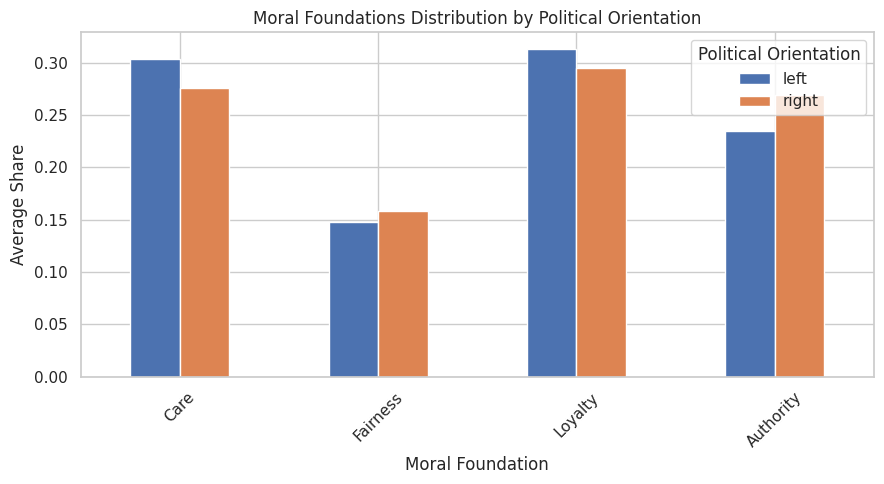

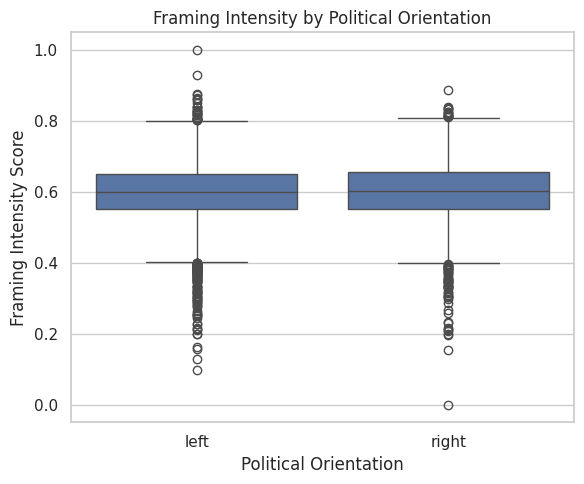

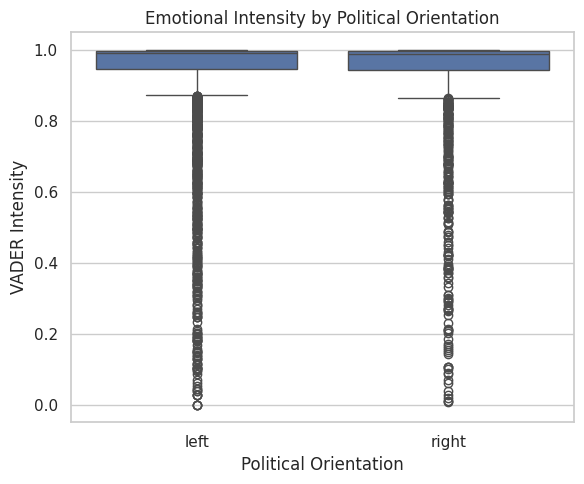

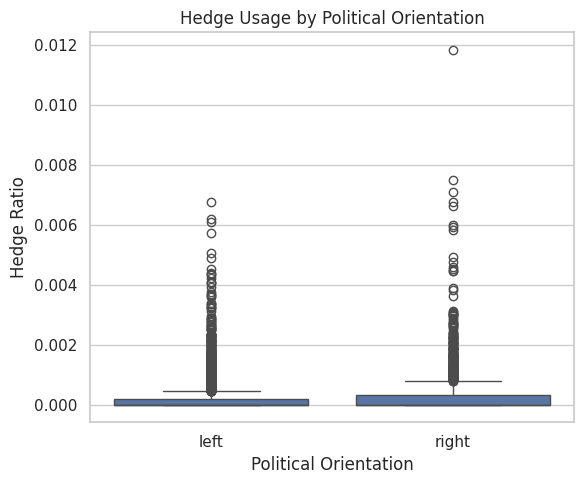

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3) Load saved CSV
save_path = "/content/drive/MyDrive/Master thesis/framing_scored.csv"
df = pd.read_csv(save_path)

print("Loaded shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

# 4) Keep clean left/right labels
df["llama_label"] = df["llama_label"].astype(str).str.lower().str.strip()
df = df[df["llama_label"].isin(["left", "right"])].copy()

print("\nLabel counts:")
print(df["llama_label"].value_counts())

# 5) Recompute moral totals + shares from saved count columns
FOUNDATIONS = ["care", "fairness", "loyalty", "authority"]

# total hits
df["mfd2_total_hits"] = df[[f"mfd2_{f}" for f in FOUNDATIONS]].sum(axis=1)

# safe shares
for f in FOUNDATIONS:
    df[f"mfd2_{f}_share"] = df[f"mfd2_{f}"] / df["mfd2_total_hits"].replace(0, np.nan)

print("\nMFD2 total hits summary:")
print(df["mfd2_total_hits"].describe())

print("\nNon-missing share counts:")
print(df[[f"mfd2_{f}_share" for f in FOUNDATIONS]].notna().sum())

# 6) Clean plotting style
sns.set_theme(style="whitegrid", context="notebook")

# =========================
# PLOT 1 — Moral foundations by political orientation
# =========================
moral_cols = [f"mfd2_{f}_share" for f in FOUNDATIONS]

summary_moral = df.groupby("llama_label")[moral_cols].mean()
summary_moral.columns = ["Care", "Fairness", "Loyalty", "Authority"]

ax = summary_moral.T.plot(kind="bar", figsize=(9, 5))
ax.set_title("Moral Foundations Distribution by Political Orientation")
ax.set_xlabel("Moral Foundation")
ax.set_ylabel("Average Share")
plt.xticks(rotation=45)
plt.legend(title="Political Orientation")
plt.tight_layout()
plt.show()

# =========================
# PLOT 2 — Framing intensity boxplot
# =========================
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="llama_label", y="framing_intensity_score")
plt.title("Framing Intensity by Political Orientation")
plt.xlabel("Political Orientation")
plt.ylabel("Framing Intensity Score")
plt.tight_layout()
plt.show()

# =========================
# PLOT 3 — Emotional intensity (VADER) boxplot
# =========================
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="llama_label", y="vader_intensity")
plt.title("Emotional Intensity by Political Orientation")
plt.xlabel("Political Orientation")
plt.ylabel("VADER Intensity")
plt.tight_layout()
plt.show()

# =========================
# PLOT 4 — Hedge ratio boxplot
# =========================
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="llama_label", y="hedge_ratio")
plt.title("Hedge Usage by Political Orientation")
plt.xlabel("Political Orientation")
plt.ylabel("Hedge Ratio")
plt.tight_layout()
plt.show()

The analysis shows that left‑ and right‑leaning texts do not differ meaningfully in overall framing intensity, but they do differ systematically in their moral foundations: left texts lean more on care and loyalty, whereas right texts rely more on authority (and somewhat fairness) language.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


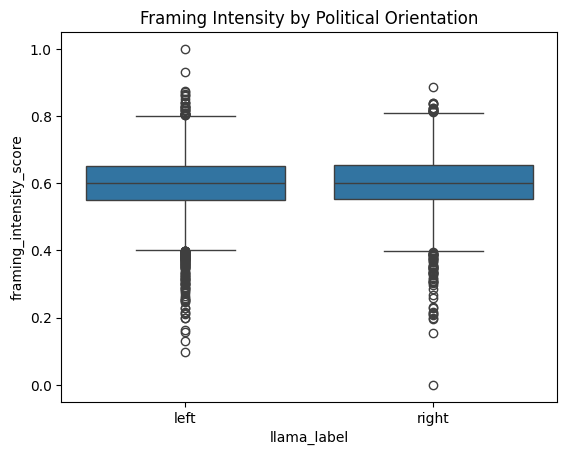

In [ ]:
import seaborn as sns

sns.boxplot(data=df, x="llama_label", y="framing_intensity_score")
plt.title("Framing Intensity by Political Orientation")
plt.show()